# Hamiltonian Monte Carlo by Hand
Let's build the leapfrog integrator ourselves then incorporate it into a full HMC sampler.

In [1]:
import numpy as np
import scipy as sp
import corner
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

## target distribution

We'll sample from a **correlated** 2D Gaussian, $p(x) = \mathcal{N}(x \mid \mu=0, \Sigma)$. 

In [2]:
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.8],
                   [0.8, 1.0]])

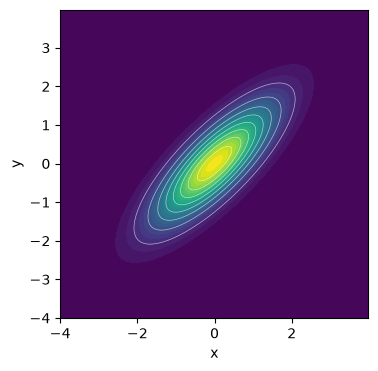

In [3]:
x, y = np.meshgrid(np.arange(-4, 4, .02), np.arange(-4, 4, .02))
pos = np.dstack((x, y))

rv = sp.stats.multivariate_normal(mu, Sigma)
z = rv.pdf(pos)

fig, ax = plt.subplots(figsize=(4, 4))
ax.contourf(x, y, z, levels=30, cmap='viridis')
ax.contour(x, y, z, levels=8, colors='white', linewidths=0.5, alpha=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

$p(x)$ has a long, correlated shape, which random walks can struggle with. 

For this target, we can evaluate the potential energy $U(x) = -\log p(x)$ and the gradient we need for leapfrog analytically:

$$\nabla \log p(\theta) = -\Sigma^{-1}(x - \mu)$$

In [4]:
Sigma_inv = np.linalg.inv(Sigma)

def grad_log_p(x):
    ''' analytic gradient of log p(x)
    '''
    return -Sigma_inv @ (x - mu)

def U(x):
    ''' potential energy U(x) = -log p(x), dropping the normalization 
    '''
    d = x - mu
    return 0.5 * d @ Sigma_inv @ d

## leapfrog integrator
One step of size $\varepsilon$: a half momentum kick

$$y(t+\varepsilon/2) = y(t) + \frac{\varepsilon}{2}\nabla\log p(x(t))$$
a full position step
$$x(t+\varepsilon) = x(t) + \varepsilon\, y(t+\varepsilon/2)$$
then the other half-kick.
$$y(t+\varepsilon) = y(t+\varepsilon/2) + \frac{\varepsilon}{2}\nabla\log p(x(t+\varepsilon))$$

In [5]:
def leapfrog(x0, y0, eps, L, grad_log_p):
    ''' take L leapfrog steps of size eps, starting from (x0, y0).
    
    Returns the full trajectory 
    '''
    x, y = x0.copy(), y0.copy()
    xs, ys = [x.copy()], [y.copy()]      

    for i in range(L): # L steps
        # initial half-kick in momentum
        y = y + 0.5 * eps * grad_log_p(x)    
    
        # full position step: x(t+eps)
        x = x + eps * y 

        # other half momentum step with gradient at x(t+eps)
        y = y + 0.5 * eps * grad_log_p(x)

        xs.append(x.copy())
        ys.append(y.copy())
        
    #y = y + 0.5 * eps * grad_log_p(x)   # final half-kick, outside the loop
        
    return np.array(xs), np.array(ys)

## lets check out the trajectory for an arbitrary intialization

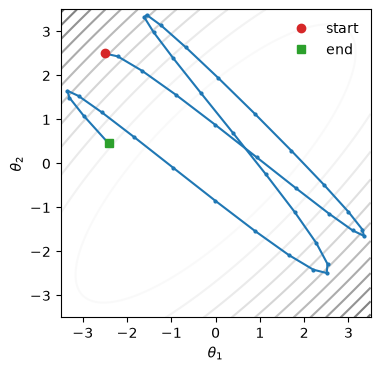

In [6]:
x0 = np.array([-2.5, 2.5])
y0 = np.array([1.0, 0.5])
eps, L = 0.15, 40

xs_lf, ys_lf = leapfrog(x0, y0, eps, L, grad_log_p)

# potential energy contours for reference
t1 = np.linspace(-3.5, 3.5, 200)
t2 = np.linspace(-3.5, 3.5, 200)
T1, T2 = np.meshgrid(t1, t2)
U_grid = np.array([[U(np.array([a, b])) for a in t1] for b in t2])

plt.figure(figsize=(4, 4))
plt.contour(T1, T2, U_grid, levels=12, cmap='Greys', alpha=0.6)
plt.plot(xs_lf[:, 0], xs_lf[:, 1], '.-', c='C0', ms=4)
plt.plot(*x0, 'o', c='C3', label='start')
plt.plot(*xs_lf[-1], 's', c='C2', label='end')
plt.xlabel(r'$\theta_1$'); plt.ylabel(r'$\theta_2$')
plt.legend(frameon=False)
plt.show()

The trajectory bends to follow the correlated valley. That's the gradient at work: it's constantly correcting the marble's path to stay on the ridge of high probability.

# full HMC 

1. initialize $x_0$
2. draw momentum $y \sim T$
3. run $L$ leapfrog steps of $\varepsilon$ from $(x, y)$ to $(x', y')$
4. accept with acceptance rate $r = \min (1, \exp(H(x,y) - H(x',y')))$; otherwise stay
5. repeat

In [7]:
def HMC(n_samples, x0, eps, L, grad_log_p, U, seed=1):
    x = x0.copy()
    samples = [x.copy()]
    
    n_accept = 0
    for _ in range(n_samples): 
        # sample momentum
        y0 = np.random.normal(size=2)                                   

        # get (x', y') using leapfrog 
        xs_traj, ys_traj = leapfrog(x, y0, eps, L, grad_log_p)
        xp, yp = xs_traj[-1], ys_traj[-1]

        # calculate acceptance rate
        # H(x, y)
        H0 = U(x) + 0.5 * np.sum(y0**2) # kinetic energy = 1/2 p^2/M, we set M to 0
        # H(x', y')
        H1 = U(xp) + 0.5 * np.sum(yp**2)
        
        log_r = H0 - H1 # log acceptance rate

        u = np.random.uniform()
        if np.log(u) < log_r:
            x = xp
            n_accept += 1
        samples.append(x.copy())
    return np.array(samples), n_accept / n_samples

In [8]:
n_samples = 4000
samples, acc_rate = HMC(n_samples, 
                        np.array([-2.5, 2.5]), 
                        eps=0.2, 
                        L=12,
                        grad_log_p=grad_log_p, U=U)
print(f'acceptance rate: {acc_rate:.1%}')

acceptance rate: 98.6%


## 5. Checking the result

Discard a short burn-in, then compare the sample covariance to the true $\Sigma$.

In [9]:
burnin = 200
post = samples[burnin:]
print('sample mean:', post.mean(axis=0), ' (true mu:', mu, ')')

sample mean: [-0.01048244  0.00082   ]  (true mu: [0. 0.] )


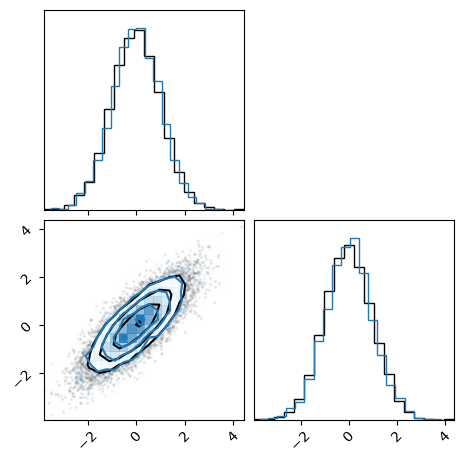

In [10]:
samples_true = rv.rvs(size=10000)
fig = corner.corner(samples_true, color='k', hist_kwargs={'density': True})
fig = corner.corner(post, color='C0', fig=fig, hist_kwargs={'density': True})

# in-class

1. vary $\varepsilon$ and $L$ and explore how it impacts the sampling. What happens when you increase $\varepsilon$? What happens when you reduce $L$? 

2. Try sampling a more correated target distribution: 
```
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.95],
                   [0.95, 1.0]])
```

acceptance rate: 83.9%
sample mean: [0.00352471 0.01960223]  (true mu: [0. 0.] )


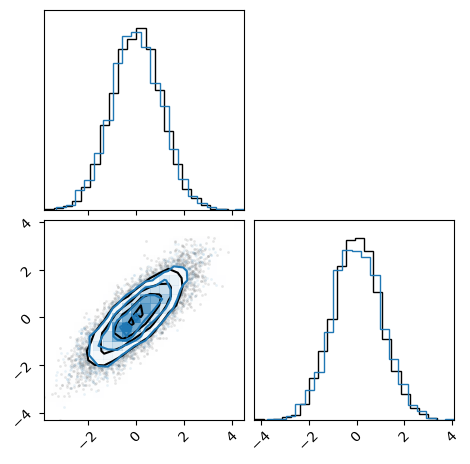

In [40]:
n_samples = 4000
samples, acc_rate = HMC(n_samples, 
                        np.array([-2.5, 2.5]), 
                        eps=0.6, 
                        L=10,
                        grad_log_p=grad_log_p, U=U)
print(f'acceptance rate: {acc_rate:.1%}')
burnin = 200
post = samples[burnin:]
print('sample mean:', post.mean(axis=0), ' (true mu:', mu, ')')
samples_true = rv.rvs(size=10000)
fig = corner.corner(samples_true, color='k', hist_kwargs={'density': True})
fig = corner.corner(post, color='C0', fig=fig, hist_kwargs={'density': True})

In [34]:

Sigma_inv = np.linalg.inv(Sigma)

def grad_log_p(x):
    ''' analytic gradient of log p(x)
    '''
    return -Sigma_inv @ (x - mu)

def U(x):
    ''' potential energy U(x) = -log p(x), dropping the normalization 
    '''
    d = x - mu
    return 0.5 * d @ Sigma_inv @ d


